In [1]:
# ============================================================
# 1. Import Library
# ============================================================

import os
import json
import numpy as np
import pandas as pd

from sklearn.model_selection import GroupShuffleSplit, StratifiedGroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import RFE
from xgboost import XGBClassifier
from imblearn.under_sampling import TomekLinks
from collections import Counter

raw_path = "d:/PENS-EEPIS/SDT A Semester 4 2026/Project TA/dataset/raw/DataCoSupplyChainDataset.csv"

df_raw = pd.read_csv(raw_path, encoding="latin1")

df = df_raw.copy()
df = df.drop_duplicates()

target_col = "Late_delivery_risk"

### Missing & Duplicate Value Handling

In [2]:
# ============================================================
# Drop Kolom Tidak Dipakai / Sensitif / Berisiko Leakage
# ============================================================

drop_cols = [
    "Product Description",
    "Product Image",
    "Product Category Id",

    "Customer Fname",
    "Customer Lname",
    "Customer Email",
    "Customer Password",
    "Customer Street",
    "Customer Zipcode",

    "Order Customer Id",
    "Order Zipcode",

    # Kolom post-delivery / leakage risk
    "Days for shipping (real)",
    "Delivery Status",
    "Late_delivery_risk",  # target akan dimasukkan lagi dari df_raw
]

existing_drop_cols = [col for col in drop_cols if col in df.columns and col != target_col]

df = df.drop(columns=existing_drop_cols)
df[target_col] = df_raw[target_col]

print("Shape setelah drop:", df.shape)

Shape setelah drop: (180519, 40)


## Feature Engineering

In [3]:
# ============================================================
# Date Feature Engineering
# Berdasarkan order date, aman karena diketahui saat order dibuat
# ============================================================

df["order_date"] = pd.to_datetime(
    df["order date (DateOrders)"],
    errors="coerce"
)

df["order_year"] = df["order_date"].dt.year
df["order_month"] = df["order_date"].dt.month
df["order_day"] = df["order_date"].dt.day
df["order_dayofweek"] = df["order_date"].dt.dayofweek
df["order_hour"] = df["order_date"].dt.hour
df["order_quarter"] = df["order_date"].dt.quarter

df["order_is_weekend"] = df["order_dayofweek"].isin([5, 6]).astype(int)
df["order_is_month_start"] = df["order_date"].dt.is_month_start.astype(int)
df["order_is_month_end"] = df["order_date"].dt.is_month_end.astype(int)

df["order_period"] = pd.cut(
    df["order_hour"],
    bins=[-1, 5, 11, 17, 23],
    labels=[0, 1, 2, 3]
).astype(float)

# 0 = malam/dini hari, 1 = pagi, 2 = siang/sore, 3 = malam

In [4]:
# ============================================================
# Shipping Mode x Scheduled Days Feature Engineering
# ============================================================

df["scheduled_days"] = df["Days for shipment (scheduled)"]

# Mapping bisnis: ekspektasi jumlah hari berdasarkan mode
shipping_mode_expected_days = {
    "Same Day": 0,
    "First Class": 1,
    "Second Class": 2,
    "Standard Class": 4
}

shipping_mode_speed_rank = {
    "Same Day": 0,
    "First Class": 1,
    "Second Class": 2,
    "Standard Class": 3
}

df["expected_scheduled_days_by_mode"] = (
    df["Shipping Mode"]
    .map(shipping_mode_expected_days)
)

df["shipping_mode_speed_rank"] = (
    df["Shipping Mode"]
    .map(shipping_mode_speed_rank)
)

# Fitur utama yang kamu minta:
# scheduled_by_mode = representasi jadwal yang dijanjikan berdasarkan mode pengiriman
df["scheduled_by_mode"] = df["expected_scheduled_days_by_mode"]

# Selisih antara scheduled_days asli dengan ekspektasi dari Shipping Mode
df["scheduled_mode_gap"] = (
    df["scheduled_days"] - df["expected_scheduled_days_by_mode"]
)

# Apakah scheduled_days konsisten dengan Shipping Mode
df["scheduled_mode_is_consistent"] = (
    df["scheduled_mode_gap"].fillna(999) == 0
).astype(int)

# Versi absolut gap
df["scheduled_mode_abs_gap"] = df["scheduled_mode_gap"].abs()

# Ratio scheduled days terhadap ekspektasi mode
df["scheduled_mode_ratio"] = (
    df["scheduled_days"] / (df["expected_scheduled_days_by_mode"] + 1)
)

# Fitur kategori kecepatan shipping
df["is_same_day_mode"] = (df["Shipping Mode"] == "Same Day").astype(int)
df["is_first_class_mode"] = (df["Shipping Mode"] == "First Class").astype(int)
df["is_second_class_mode"] = (df["Shipping Mode"] == "Second Class").astype(int)
df["is_standard_class_mode"] = (df["Shipping Mode"] == "Standard Class").astype(int)

# Fitur dari scheduled_days
df["is_fast_shipping"] = (df["scheduled_days"] <= 1).astype(int)
df["is_medium_shipping"] = df["scheduled_days"].between(2, 3).astype(int)
df["is_slow_shipping"] = (df["scheduled_days"] >= 4).astype(int)

# Interaction sederhana
df["speed_rank_x_scheduled_days"] = (
    df["shipping_mode_speed_rank"] * df["scheduled_days"]
)

df["fast_mode_but_long_schedule"] = (
    (df["shipping_mode_speed_rank"] <= 1) &
    (df["scheduled_days"] >= 2)
).astype(int)

df["slow_mode_but_short_schedule"] = (
    (df["shipping_mode_speed_rank"] >= 2) &
    (df["scheduled_days"] <= 1)
).astype(int)


In [5]:
# ============================================================
# Order Value / Pricing Feature Engineering
# Aman karena berasal dari informasi order
# ============================================================

df["order_quantity"] = df["Order Item Quantity"]

df["gross_item_value"] = (
    df["Product Price"] * df["Order Item Quantity"]
)

df["net_item_value"] = df["Order Item Total"]

df["discount_amount"] = df["Order Item Discount"]
df["discount_rate"] = df["Order Item Discount Rate"]

df["discount_per_item"] = (
    df["Order Item Discount"] / (df["Order Item Quantity"] + 1e-6)
)

df["sales_per_item"] = (
    df["Sales"] / (df["Order Item Quantity"] + 1e-6)
)

df["price_gap"] = (
    df["Product Price"] - df["Order Item Product Price"]
)

df["discount_to_gross_ratio"] = (
    df["discount_amount"] / (df["gross_item_value"] + 1e-6)
)

df["net_to_gross_ratio"] = (
    df["net_item_value"] / (df["gross_item_value"] + 1e-6)
)

bulk_threshold = df["Order Item Quantity"].quantile(0.75)

df["is_bulk_order"] = (
    df["Order Item Quantity"] >= bulk_threshold
).astype(int)


In [6]:
# ============================================================
# Geographic Feature Engineering
# ============================================================

df["abs_latitude"] = df["Latitude"].abs()
df["abs_longitude"] = df["Longitude"].abs()

df["geo_distance_proxy"] = np.sqrt(
    df["Latitude"].fillna(0) ** 2 +
    df["Longitude"].fillna(0) ** 2
)


In [7]:
# ============================================================
# Pilih Kolom Model-Ready
# Tidak memasukkan Shipping Mode mentah agar tidak redundant
# Tidak memasukkan kolom post-delivery
# ============================================================

model_ready_cols = [
    target_col,

    # dipakai untuk group split, bukan fitur training
    "Order Id",

    # lokasi
    "Latitude",
    "Longitude",
    "abs_latitude",
    "abs_longitude",
    "geo_distance_proxy",

    # date features
    "order_year",
    "order_month",
    "order_day",
    "order_dayofweek",
    "order_hour",
    "order_quarter",
    "order_period",
    "order_is_weekend",
    "order_is_month_start",
    "order_is_month_end",

    # shipping features utama
    "scheduled_days",
    "scheduled_by_mode",
    "expected_scheduled_days_by_mode",
    "shipping_mode_speed_rank",
    "scheduled_mode_gap",
    "scheduled_mode_abs_gap",
    "scheduled_mode_ratio",
    "scheduled_mode_is_consistent",

    # shipping binary features
    "is_same_day_mode",
    "is_first_class_mode",
    "is_second_class_mode",
    "is_standard_class_mode",
    "is_fast_shipping",
    "is_medium_shipping",
    "is_slow_shipping",

    # shipping interaction features
    "speed_rank_x_scheduled_days",
    "fast_mode_but_long_schedule",
    "slow_mode_but_short_schedule",

    # order value features
    "order_quantity",
    "gross_item_value",
    "net_item_value",
    "discount_amount",
    "discount_rate",
    "discount_per_item",
    "sales_per_item",
    "price_gap",
    "discount_to_gross_ratio",
    "net_to_gross_ratio",
    "is_bulk_order",
]

df_model_ready = df[model_ready_cols].copy()

print("Shape model-ready:", df_model_ready.shape)
df_model_ready.head()

Shape model-ready: (180519, 46)


,Late_delivery_risk,Order Id,Latitude,Longitude,abs_latitude,abs_longitude,geo_distance_proxy,order_year,order_month,order_day,...,gross_item_value,net_item_value,discount_amount,discount_rate,discount_per_item,sales_per_item,price_gap,discount_to_gross_ratio,net_to_gross_ratio,is_bulk_order
0,0,77202,18.251453,-66.037056,18.251453,66.037056,68.512833,2018,1,31,...,327.75,314.640015,13.110000,0.04,13.109987,327.749672,0.0,0.040000,0.960000,0
1,1,75939,18.279451,-66.037064,18.279451,66.037064,68.520304,2018,1,13,...,327.75,311.359985,16.389999,0.05,16.389983,327.749672,0.0,0.050008,0.949992,0
2,0,75938,37.292233,-121.881279,37.292233,121.881279,127.458843,2018,1,13,...,327.75,309.720001,18.030001,0.06,18.029983,327.749672,0.0,0.055011,0.944989,0
3,0,75937,34.125946,-118.291016,34.125946,118.291016,123.115168,2018,1,13,...,327.75,304.809998,22.940001,0.07,22.939978,327.749672,0.0,0.069992,0.930008,0
4,0,75936,18.253769,-66.037048,18.253769,66.037048,68.513443,2018,1,13,...,327.75,298.250000,29.500000,0.09,29.499971,327.749672,0.0,0.090008,0.909992,0


## Preprocessing

### Missing Value Handling

In [8]:
# ============================================================
# Missing Value Handling
# ============================================================

df_model_ready = df_model_ready.dropna(subset=[target_col, "Order Id"])

feature_cols = [
    col for col in df_model_ready.columns
    if col not in [target_col, "Order Id"]
]

for col in feature_cols:
    median_value = df_model_ready[col].median()
    df_model_ready[col] = df_model_ready[col].fillna(median_value)

print("Missing values:")
display(df_model_ready.isnull().sum().sort_values(ascending=False))

Missing values:


Late_delivery_risk                 0
slow_mode_but_short_schedule       0
is_same_day_mode                   0
is_first_class_mode                0
is_second_class_mode               0
is_standard_class_mode             0
is_fast_shipping                   0
is_medium_shipping                 0
is_slow_shipping                   0
speed_rank_x_scheduled_days        0
fast_mode_but_long_schedule        0
order_quantity                     0
Order Id                           0
gross_item_value                   0
net_item_value                     0
discount_amount                    0
discount_rate                      0
discount_per_item                  0
sales_per_item                     0
price_gap                          0
discount_to_gross_ratio            0
net_to_gross_ratio                 0
scheduled_mode_is_consistent       0
scheduled_mode_ratio               0
scheduled_mode_abs_gap             0
scheduled_mode_gap                 0
Latitude                           0
L

In [9]:
# ============================================================
# 7. Simpan Dataset Feature Engineering Sebelum Split
# ============================================================

engineered_dir = "d:/PENS-EEPIS/SDT A Semester 4 2026/Project TA/dataset/engineered"
os.makedirs(engineered_dir, exist_ok=True)

classification_path = os.path.join(engineered_dir, "data_Classification.csv")

df_model_ready.to_csv(classification_path, index=False)

print("Saved:", classification_path)
print(df_model_ready.shape)

Saved: d:/PENS-EEPIS/SDT A Semester 4 2026/Project TA/dataset/engineered\data_Classification.csv
(180519, 46)


### Splitting

In [10]:
# ============================================================
# 8. Split Train, Valid, Test dengan Group berdasarkan Order Id
# ============================================================

target = "Late_delivery_risk"

X = df_model_ready.drop(columns=[target])
y = df_model_ready[target].astype(int)
groups = df_model_ready["Order Id"]

# Holdout test 20%
gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

train_valid_idx, test_idx = next(gss.split(X, y, groups))

X_train_valid = X.iloc[train_valid_idx].copy()
y_train_valid = y.iloc[train_valid_idx].copy()
groups_train_valid = groups.iloc[train_valid_idx].copy()

X_test = X.iloc[test_idx].copy()
y_test = y.iloc[test_idx].copy()

# Validasi dari train_valid pakai StratifiedGroupKFold
sgkf = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

train_idx, valid_idx = next(
    sgkf.split(X_train_valid, y_train_valid, groups_train_valid)
)

X_train = X_train_valid.iloc[train_idx].copy()
y_train = y_train_valid.iloc[train_idx].copy()

X_valid = X_train_valid.iloc[valid_idx].copy()
y_valid = y_train_valid.iloc[valid_idx].copy()

print("Train:", X_train.shape, Counter(y_train))
print("Valid:", X_valid.shape, Counter(y_valid))
print("Test :", X_test.shape, Counter(y_test))

Train: (115823, 45) Counter({1: 63531, 0: 52292})
Valid: (28827, 45) Counter({1: 15777, 0: 13050})
Test : (35869, 45) Counter({1: 19669, 0: 16200})


In [11]:
# ============================================================
# 9. Drop Order Id dari Fitur Training
# ============================================================

X_train = X_train.drop(columns=["Order Id"])
X_valid = X_valid.drop(columns=["Order Id"])
X_test = X_test.drop(columns=["Order Id"])

print("Jumlah fitur sebelum scaling:", X_train.shape[1])

Jumlah fitur sebelum scaling: 44


### Outllier Handling

In [12]:
outlier_cols = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()

outlier_bounds = {}

for col in outlier_cols:
    q1 = X_train[col].quantile(0.25)
    q3 = X_train[col].quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outlier_bounds[col] = {
        "lower": lower_bound,
        "upper": upper_bound
    }

    X_train[col] = X_train[col].clip(lower=lower_bound, upper=upper_bound)
    X_valid[col] = X_valid[col].clip(lower=lower_bound, upper=upper_bound)
    X_test[col] = X_test[col].clip(lower=lower_bound, upper=upper_bound)

In [13]:
# ============================================================
# Print Ringkasan Outlier Setelah IQR Capping
# ============================================================

outlier_summary = []

for col in outlier_cols:
    lower_bound = outlier_bounds[col]["lower"]
    upper_bound = outlier_bounds[col]["upper"]

    # Hitung dari data sebelum capping kalau tersedia
    # Jika tidak punya backup sebelum capping, bagian ini tetap menampilkan batasnya.
    capped_lower_train = (X_train[col] == lower_bound).sum()
    capped_upper_train = (X_train[col] == upper_bound).sum()

    capped_lower_valid = (X_valid[col] == lower_bound).sum()
    capped_upper_valid = (X_valid[col] == upper_bound).sum()

    capped_lower_test = (X_test[col] == lower_bound).sum()
    capped_upper_test = (X_test[col] == upper_bound).sum()

    outlier_summary.append({
        "feature": col,
        "lower_bound": lower_bound,
        "upper_bound": upper_bound,
        "train_capped_lower": capped_lower_train,
        "train_capped_upper": capped_upper_train,
        "valid_capped_lower": capped_lower_valid,
        "valid_capped_upper": capped_upper_valid,
        "test_capped_lower": capped_lower_test,
        "test_capped_upper": capped_upper_test,
        "total_capped": (
            capped_lower_train + capped_upper_train +
            capped_lower_valid + capped_upper_valid +
            capped_lower_test + capped_upper_test
        )
    })

outlier_summary_df = pd.DataFrame(outlier_summary)

outlier_summary_df = outlier_summary_df.sort_values(
    by="total_capped",
    ascending=False
)

outlier_summary_df

,feature,lower_bound,upper_bound,train_capped_lower,train_capped_upper,valid_capped_lower,valid_capped_upper,test_capped_lower,test_capped_upper,total_capped
21,price_gap,0.000000,0.000000,115823,115823,28827,28827,35869,35869,361038
10,scheduled_mode_gap,0.000000,0.000000,115823,115823,28827,28827,35869,35869,361038
11,scheduled_mode_abs_gap,0.000000,0.000000,115823,115823,28827,28827,35869,35869,361038
19,discount_per_item,-18.349978,38.049959,0,11622,0,2872,0,3713,18207
12,scheduled_mode_ratio,0.466667,1.000000,6196,0,1571,0,1970,0,9737
9,shipping_mode_speed_rank,0.500000,4.500000,6196,0,1571,0,1970,0,9737
17,discount_amount,-31.235000,66.724999,0,4894,0,1182,0,1461,7537
20,sales_per_item,-174.984833,424.974589,0,1296,0,323,0,429,2048
16,net_item_value,-110.149998,461.929989,0,1226,0,329,0,388,1943
1,Longitude,-146.750908,-18.142387,749,130,185,60,253,37,1414


In [14]:
# ============================================================
# 10. Standardisasi Numeric Feature
#     Fit hanya di train, transform valid/test
# ============================================================

ignore_cols = [['Latitude', 'Longitude', 'Shipping Mode_encoded']] 
numeric_cols = X_train.columns.tolist()
numeric_cols = [col for col in numeric_cols if col not in ignore_cols]

scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_valid_scaled = pd.DataFrame(
    scaler.transform(X_valid),
    columns=X_valid.columns,
    index=X_valid.index
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

print(X_train_scaled.shape)
print(X_valid_scaled.shape)
print(X_test_scaled.shape)

(115823, 44)
(28827, 44)
(35869, 44)


### Feature Selection

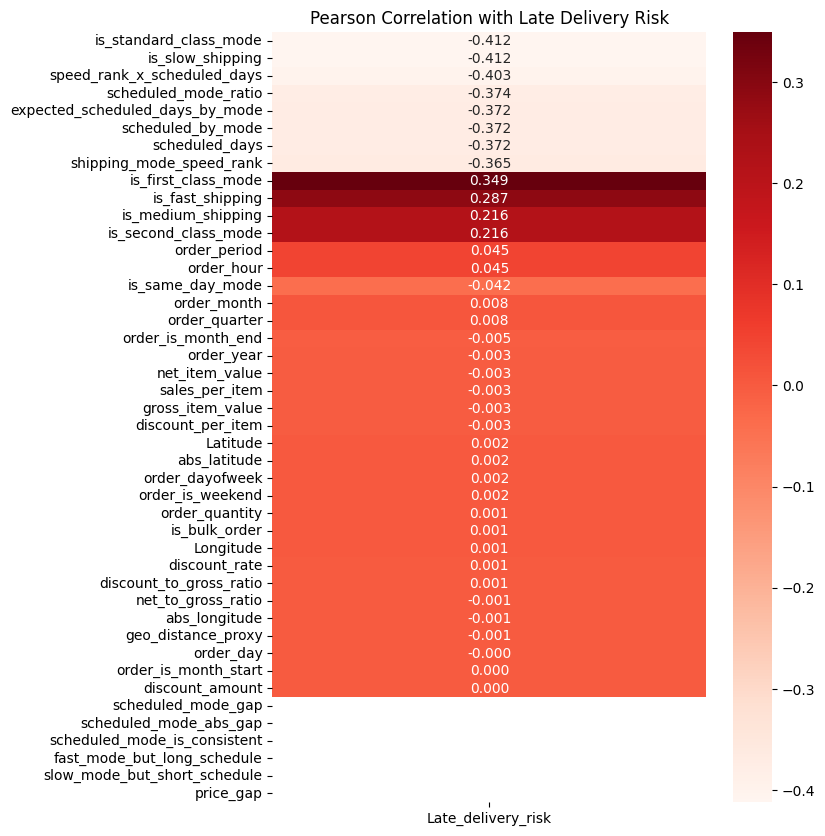

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

target = "Late_delivery_risk"

train_corr_df = X_train_scaled.copy()
train_corr_df[target] = y_train.values

corr_matrix = train_corr_df.corr(numeric_only=True)

target_correlation = (
    corr_matrix[[target]]
    .drop(index=target)
    .sort_values(by=target, key=lambda x: x.abs(), ascending=False)
)

plt.figure(figsize=(7, 10))
sns.heatmap(
    target_correlation,
    annot=True,
    cmap="Reds",
    fmt=".3f"
)
plt.title("Pearson Correlation with Late Delivery Risk")
plt.show()


In [16]:
# ============================================================
# 11. Feature Selection dengan RFE
#     Fit hanya di train
# ============================================================

base_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

rfe = RFE(
    estimator=base_model,
    n_features_to_select=10,
    step=1
)

rfe.fit(X_train_scaled, y_train)

selected_features = X_train_scaled.columns[rfe.support_].tolist()

X_train_selected = X_train_scaled[selected_features].copy()
X_valid_selected = X_valid_scaled[selected_features].copy()
X_test_selected = X_test_scaled[selected_features].copy()

print("Selected features:")
selected_features

Selected features:


['Latitude',
 'geo_distance_proxy',
 'order_hour',
 'order_period',
 'scheduled_days',
 'scheduled_by_mode',
 'expected_scheduled_days_by_mode',
 'is_first_class_mode',
 'is_second_class_mode',
 'is_medium_shipping']

In [17]:
# ============================================================
# 12. Optional: TomekLinks hanya untuk Train
#     Valid dan Test tidak boleh di-resampling
# ============================================================

tomek = TomekLinks(
    sampling_strategy="auto",
    n_jobs=-1
)

print("Before TomekLinks:", Counter(y_train))

X_train_tomek, y_train_tomek = tomek.fit_resample(
    X_train_selected,
    y_train
)

print("After TomekLinks:", Counter(y_train_tomek))

Before TomekLinks: Counter({1: 63531, 0: 52292})
After TomekLinks: Counter({1: 63102, 0: 52292})


In [18]:
# ============================================================
# 13. Buat DataFrame Final Siap Training
# ============================================================

df_train = pd.concat(
    [
        pd.DataFrame(X_train_tomek, columns=selected_features),
        pd.Series(y_train_tomek, name=target)
    ],
    axis=1
)

df_valid = pd.concat(
    [
        X_valid_selected.reset_index(drop=True),
        y_valid.reset_index(drop=True).rename(target)
    ],
    axis=1
)

df_test = pd.concat(
    [
        X_test_selected.reset_index(drop=True),
        y_test.reset_index(drop=True).rename(target)
    ],
    axis=1
)

print("df_train:", df_train.shape)
print("df_valid:", df_valid.shape)
print("df_test :", df_test.shape)

df_train: (115394, 11)
df_valid: (28827, 11)
df_test : (35869, 11)


In [19]:
# ============================================================
# 14. Simpan CSV Output Final
# ============================================================

output_dir = "d:/PENS-EEPIS/SDT A Semester 4 2026/Project TA/dataset/engineered/"
os.makedirs(output_dir, exist_ok=True)

train_path = os.path.join(output_dir, "df_train.csv")
valid_path = os.path.join(output_dir, "df_valid.csv")
test_path = os.path.join(output_dir, "df_test.csv")
features_path = os.path.join(output_dir, "selected_features_risk.json")

df_train.to_csv(train_path, index=False)
df_valid.to_csv(valid_path, index=False)
df_test.to_csv(test_path, index=False)

with open(features_path, "w", encoding="utf-8") as f:
    json.dump(selected_features, f, indent=4)

print("Saved train:", train_path)
print("Saved valid:", valid_path)
print("Saved test :", test_path)
print("Saved features:", features_path)

Saved train: d:/PENS-EEPIS/SDT A Semester 4 2026/Project TA/dataset/engineered/df_train.csv
Saved valid: d:/PENS-EEPIS/SDT A Semester 4 2026/Project TA/dataset/engineered/df_valid.csv
Saved test : d:/PENS-EEPIS/SDT A Semester 4 2026/Project TA/dataset/engineered/df_test.csv
Saved features: d:/PENS-EEPIS/SDT A Semester 4 2026/Project TA/dataset/engineered/selected_features_risk.json
